# Notebook 4: Buscador Semántico y Evaluación

**Proyecto Final - Inteligencia Artificial**

Este es el notebook donde **comparamos los 5 enfoques** sobre la tarea de búsqueda semántica:

1. **TF-IDF** (baseline clásica, palabras exactas).
2. **Word2Vec PyTorch** (nuestra implementación desde cero).
3. **Word2Vec gensim** (mismo modelo, implementación de referencia).
4. **GloVe** (preentrenado en español).
5. **Sentence-Transformers** (BERT multilingüe).

## Dataset de evaluación: mMARCO en español

mMARCO es la versión multilingüe del célebre MS MARCO. Contiene pares (query, pasaje relevante) usados para entrenar y evaluar buscadores. Usamos un subconjunto manejable para que la evaluación sea rápida.

## Métricas

- **Precision@K** ($K \in \{1, 5, 10\}$): fracción de los top-K resultados que son relevantes.
- **Mean Reciprocal Rank (MRR)**: promedio de $1/\text{rank}$ del primer resultado relevante.




## 1. Instalación e imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/proyecto_ia_final"
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Trabajando en: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Trabajando en: /content/drive/MyDrive/proyecto_ia_final


In [ ]:
!pip install "datasets<3.0" --quiet

In [ ]:
!pip install datasets scikit-learn sentence-transformers -q

In [ ]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

DATA_DIR = Path("data")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")


Dispositivo: cpu


## 2. Cargar vocabulario y embeddings de los notebooks previos

In [ ]:
with open(DATA_DIR / "vocab.json", "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
word2id = vocab_data["word2id"]
id2word = {int(k): v for k, v in vocab_data["id2word"].items()}
VOCAB_SIZE = vocab_data["vocab_size"]

# Cargar todas las matrices de embeddings
w2v_pytorch = np.load(DATA_DIR / "word2vec_pytorch.npy")
w2v_gensim  = np.load(DATA_DIR / "word2vec_gensim.npy")
glove       = np.load(DATA_DIR / "glove_aligned.npy")
glove_mask  = np.load(DATA_DIR / "glove_vocab_mask.npy")

print(f"Vocabulario:     {VOCAB_SIZE:,} palabras")
print(f"w2v PyTorch:     {w2v_pytorch.shape}")
print(f"w2v gensim:      {w2v_gensim.shape}")
print(f"GloVe:           {glove.shape} (cobertura: {glove_mask.sum():,} palabras)")


Vocabulario:     80,000 palabras
w2v PyTorch:     (80000, 100)
w2v gensim:      (80000, 100)
GloVe:           (80000, 300) (cobertura: 79,089 palabras)


## 3. Cargar mMARCO en español

Usamos `unicamp-dl/mmarco` en HuggingFace. Tomamos un subconjunto de documentos y queries con sus pares de relevancia.

In [ ]:
# Configuración del subconjunto
N_DOCS = 5000      # Número de documentos del corpus
N_QUERIES = 200    # Número de queries a evaluar
SEED = 42

np.random.seed(SEED)

print("Cargando mMARCO (puede tardar unos minutos)...")

# mMARCO tiene varias configuraciones. Usamos la versión "spanish" con pares query-passage.
# Estructura: cada ejemplo tiene query, positive (pasaje relevante), negative (no relevante)
try:
    ds_pairs = load_dataset("unicamp-dl/mmarco", "spanish", split="train", streaming=True)
except Exception as e:
    print(f"Falló la primera opción ({e}). Intentando alternativa...")
    ds_pairs = load_dataset("unicamp-dl/mmarco", "queries-spanish", split="train", streaming=True)

# Tomar N_QUERIES + algunos más por si hay duplicados
samples = []
for i, ex in enumerate(ds_pairs):
    if i >= N_QUERIES * 3:
        break
    samples.append(ex)

print(f"Ejemplos cargados: {len(samples)}")
print(f"Estructura del primer ejemplo: {list(samples[0].keys())}")
print(f"Ejemplo:")
for k, v in samples[0].items():
    v_str = str(v)
    print(f"  {k}: {v_str[:150]}{'...' if len(v_str) > 150 else ''}")


Cargando mMARCO (puede tardar unos minutos)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The repository for unicamp-dl/mmarco contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/unicamp-dl/mmarco.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Repo card metadata block was not found. Setting CardData to empty.


Ejemplos cargados: 600
Estructura del primer ejemplo: ['query', 'positive', 'negative']
Ejemplo:
  query: está bien un poco de cafeína durante el embarazo
  positive: No sabemos mucho sobre los efectos de la cafeína durante el embarazo en usted y su bebé. Por lo tanto, es mejor limitar la cantidad que recibe cada dí...
  negative: En general, es seguro para las mujeres embarazadas comer chocolate porque los estudios han demostrado demostrar ciertos beneficios de comer chocolate ...


In [ ]:
# Extraer queries y pasajes relevantes
# mMARCO en formato pairs tiene 'query' y 'positive' (pasaje relevante)
queries_data = []
all_passages = set()  # usamos set para deduplicar

for ex in samples:
    # Detectar nombres de campos (varían entre versiones de mMARCO)
    if 'query' in ex:
        query = ex['query']
    elif 'question' in ex:
        query = ex['question']
    else:
        continue

    if 'positive' in ex:
        positive = ex['positive']
    elif 'passage' in ex:
        positive = ex['passage']
    elif 'positive_passages' in ex:
        positive = ex['positive_passages'][0] if ex['positive_passages'] else None
    else:
        continue

    if not positive:
        continue

    queries_data.append({'query': query, 'positive': positive})
    all_passages.add(positive)

# Tomar solo N_QUERIES queries únicas
seen_queries = set()
unique_queries = []
for q in queries_data:
    if q['query'] not in seen_queries:
        unique_queries.append(q)
        seen_queries.add(q['query'])
    if len(unique_queries) >= N_QUERIES:
        break

print(f"Queries únicas extraídas: {len(unique_queries)}")
print(f"Pasajes relevantes únicos: {len(all_passages)}")


Queries únicas extraídas: 200
Pasajes relevantes únicos: 600


In [ ]:
# Construir el corpus de búsqueda
# Todos los pasajes relevantes (para que cada query tenga al menos un doc relevante)

# Cargar más ejemplos como distractores
print("Recolectando distractores...")
distractors = set()
try:
    ds_distractors = load_dataset("unicamp-dl/mmarco", "spanish", split="train", streaming=True)
except:
    ds_distractors = load_dataset("unicamp-dl/mmarco", "queries-spanish", split="train", streaming=True)

target_distractors = N_DOCS - len(all_passages)
for i, ex in enumerate(ds_distractors):
    if len(distractors) >= target_distractors:
        break
    if 'positive' in ex and ex['positive']:
        passage = ex['positive']
    elif 'passage' in ex and ex['passage']:
        passage = ex['passage']
    else:
        continue
    if passage not in all_passages:
        distractors.add(passage)

# Combinar
all_docs = list(all_passages) + list(distractors)
np.random.shuffle(all_docs)
all_docs = all_docs[:N_DOCS]

# Mapeo de pasaje -> índice en el corpus
doc2idx = {doc: i for i, doc in enumerate(all_docs)}

# Construir queries con el índice del doc relevante
eval_queries = []
for q in unique_queries:
    if q['positive'] in doc2idx:
        eval_queries.append({
            'query': q['query'],
            'relevant_idx': doc2idx[q['positive']]
        })

print(f"\nCorpus de búsqueda: {len(all_docs):,} documentos")
print(f"Queries evaluables: {len(eval_queries):,}")
print(f"\nEjemplo de query: '{eval_queries[0]['query']}'")
print(f"Doc relevante (truncado): '{all_docs[eval_queries[0]['relevant_idx']][:200]}...'")


Recolectando distractores...


Repo card metadata block was not found. Setting CardData to empty.



Corpus de búsqueda: 5,000 documentos
Queries evaluables: 200

Ejemplo de query: 'está bien un poco de cafeína durante el embarazo'
Doc relevante (truncado): 'No sabemos mucho sobre los efectos de la cafeína durante el embarazo en usted y su bebé. Por lo tanto, es mejor limitar la cantidad que recibe cada día. Si está embarazada, limite la cafeína a 200 mil...'


## 4. Función de tokenización

La misma que usamos en el Notebook 1 para mantener consistencia.

In [ ]:
CLEAN_RE = re.compile(r"[^a-záéíóúñü\s]", re.IGNORECASE)

def tokenize(text):
    text = text.lower()
    text = CLEAN_RE.sub(" ", text)
    return [t for t in text.split() if len(t) >= 2]

print(f"Tokenizando documentos y queries...")
doc_tokens = [tokenize(d) for d in tqdm(all_docs, desc="Docs")]
query_tokens = [tokenize(q['query']) for q in tqdm(eval_queries, desc="Queries")]


Tokenizando documentos y queries...


Docs:   0%|          | 0/5000 [00:00<?, ?it/s]

Queries:   0%|          | 0/200 [00:00<?, ?it/s]

## 5. Construir embeddings de documentos

Para los modelos de **palabra** (word2vec, GloVe), el embedding de un documento es el **promedio de los embeddings de sus palabras** (mean pooling). Es la estrategia más simple y sorprendentemente efectiva.

Para **SBERT**, codificamos el documento completo directamente.

In [ ]:
def embed_text_with_word_embeddings(tokens, embeddings_matrix, word2id, mask=None):

    vecs = []
    for tok in tokens:
        if tok in word2id:
            idx = word2id[tok]
            if mask is None or mask[idx]:
                vecs.append(embeddings_matrix[idx])
    if not vecs:
        return np.zeros(embeddings_matrix.shape[1], dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)


print("Codificando documentos con embeddings de palabra (mean pooling)...")

# Word2Vec PyTorch
doc_emb_w2v_pytorch = np.stack([
    embed_text_with_word_embeddings(toks, w2v_pytorch, word2id)
    for toks in tqdm(doc_tokens, desc="w2v PyTorch")
])
query_emb_w2v_pytorch = np.stack([
    embed_text_with_word_embeddings(toks, w2v_pytorch, word2id)
    for toks in query_tokens
])

# Word2Vec gensim
doc_emb_w2v_gensim = np.stack([
    embed_text_with_word_embeddings(toks, w2v_gensim, word2id)
    for toks in tqdm(doc_tokens, desc="w2v gensim")
])
query_emb_w2v_gensim = np.stack([
    embed_text_with_word_embeddings(toks, w2v_gensim, word2id)
    for toks in query_tokens
])

# GloVe (con máscara)
doc_emb_glove = np.stack([
    embed_text_with_word_embeddings(toks, glove, word2id, mask=glove_mask)
    for toks in tqdm(doc_tokens, desc="GloVe")
])
query_emb_glove = np.stack([
    embed_text_with_word_embeddings(toks, glove, word2id, mask=glove_mask)
    for toks in query_tokens
])

print(f"\nShapes:")
print(f"  w2v PyTorch: docs {doc_emb_w2v_pytorch.shape}, queries {query_emb_w2v_pytorch.shape}")
print(f"  w2v gensim:  docs {doc_emb_w2v_gensim.shape}, queries {query_emb_w2v_gensim.shape}")
print(f"  GloVe:       docs {doc_emb_glove.shape}, queries {query_emb_glove.shape}")


Codificando documentos con embeddings de palabra (mean pooling)...


w2v PyTorch:   0%|          | 0/5000 [00:00<?, ?it/s]

w2v gensim:   0%|          | 0/5000 [00:00<?, ?it/s]

GloVe:   0%|          | 0/5000 [00:00<?, ?it/s]


Shapes:
  w2v PyTorch: docs (5000, 100), queries (200, 100)
  w2v gensim:  docs (5000, 100), queries (200, 100)
  GloVe:       docs (5000, 300), queries (200, 300)


In [ ]:
# SBERT - codifica los textos completos sin necesidad de tokenizar a mano
print("Cargando modelo SBERT...")
sbert = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2").to(device)

print("Codificando documentos con SBERT...")
doc_emb_sbert = sbert.encode(
    all_docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)
print("Codificando queries con SBERT...")
query_emb_sbert = sbert.encode(
    [q['query'] for q in eval_queries],
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False
)
print(f"SBERT shapes: docs {doc_emb_sbert.shape}, queries {query_emb_sbert.shape}")


Cargando modelo SBERT...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Codificando documentos con SBERT...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Codificando queries con SBERT...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

SBERT shapes: docs (5000, 384), queries (200, 384)


## 6. Baseline: TF-IDF

Construimos un vectorizador TF-IDF clásico sobre los documentos. Para cada query, calculamos similitud coseno contra todos los documentos.

In [ ]:
print("Construyendo TF-IDF...")

# Usamos los tokens ya limpios, reuniéndolos como string para sklearn
docs_str = [" ".join(toks) for toks in doc_tokens]
queries_str = [" ".join(toks) for toks in query_tokens]

tfidf = TfidfVectorizer(min_df=2, max_df=0.95, sublinear_tf=True)
doc_emb_tfidf = tfidf.fit_transform(docs_str)
query_emb_tfidf = tfidf.transform(queries_str)

print(f"TF-IDF shape: docs {doc_emb_tfidf.shape}, queries {query_emb_tfidf.shape}")
print(f"(Es una matriz dispersa porque la mayoría de entradas son cero)")


Construyendo TF-IDF...
TF-IDF shape: docs (5000, 12660), queries (200, 12660)
(Es una matriz dispersa porque la mayoría de entradas son cero)


## 7. Función de evaluación

Para cada método, calculamos:
- **Precision@K** para K = 1, 5, 10.
- **MRR** (Mean Reciprocal Rank).

In [ ]:
def evaluate_search(query_embs, doc_embs, eval_queries, name=""):

    print(f"Evaluando {name}...")

    # Calcular similitudes (cosine_similarity de sklearn maneja denso y disperso)
    sims = cosine_similarity(query_embs, doc_embs)  # (n_queries, n_docs)

    # Para cada query, rankear documentos
    rankings = np.argsort(-sims, axis=1)

    # Calcular métricas
    p_at_k = {1: 0, 5: 0, 10: 0}
    mrr = 0.0

    for i, q in enumerate(eval_queries):
        relevant = q['relevant_idx']
        ranking = rankings[i]

        # Posición del documento relevante en el ranking
        pos = np.where(ranking == relevant)[0][0]
        rank = pos + 1

        # MRR
        mrr += 1.0 / rank

        # Precision@K (hay UN solo doc relevante por query, así que P@K = 1 si está entre los K)
        for k in p_at_k:
            if pos < k:
                p_at_k[k] += 1

    n = len(eval_queries)
    results = {
        'name': name,
        'P@1':  p_at_k[1]  / n,
        'P@5':  p_at_k[5]  / n,
        'P@10': p_at_k[10] / n,
        'MRR':  mrr / n,
    }
    return results


In [ ]:
# Ejecutar evaluación para cada método
all_results = []

all_results.append(evaluate_search(
    query_emb_tfidf, doc_emb_tfidf, eval_queries, "TF-IDF"
))
all_results.append(evaluate_search(
    query_emb_w2v_pytorch, doc_emb_w2v_pytorch, eval_queries, "Word2Vec (PyTorch)"
))
all_results.append(evaluate_search(
    query_emb_w2v_gensim, doc_emb_w2v_gensim, eval_queries, "Word2Vec (gensim)"
))
all_results.append(evaluate_search(
    query_emb_glove, doc_emb_glove, eval_queries, "GloVe (SBWC)"
))
all_results.append(evaluate_search(
    query_emb_sbert, doc_emb_sbert, eval_queries, "Sentence-Transformers"
))


Evaluando TF-IDF...
Evaluando Word2Vec (PyTorch)...
Evaluando Word2Vec (gensim)...
Evaluando GloVe (SBWC)...
Evaluando Sentence-Transformers...


## 8. Tabla de resultados

In [ ]:
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index('name')

# Formatear como porcentajes
df_display = df_results.copy()
for col in df_display.columns:
    df_display[col] = df_display[col].apply(lambda x: f"{x*100:.2f}%")

print("=" * 65)
print(f"RESULTADOS DE EVALUACIÓN  ({len(eval_queries)} queries, {len(all_docs)} docs)")
print("=" * 65)
print(df_display.to_string())
print("=" * 65)

# Guardar resultados
df_results.to_csv(DATA_DIR / "evaluation_results.csv")
print(f"\nResultados guardados en data/evaluation_results.csv")


RESULTADOS DE EVALUACIÓN  (200 queries, 5000 docs)
                          P@1     P@5    P@10     MRR
name                                                 
TF-IDF                 54.00%  79.00%  82.50%  64.59%
Word2Vec (PyTorch)     38.00%  60.50%  71.50%  49.65%
Word2Vec (gensim)      35.00%  62.00%  69.50%  46.62%
GloVe (SBWC)           30.00%  49.50%  57.00%  38.99%
Sentence-Transformers  63.00%  83.00%  88.50%  72.29%

Resultados guardados en data/evaluation_results.csv


/tmp/ipykernel_18437/2620412984.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_results.index, rotation=20, ha='right')


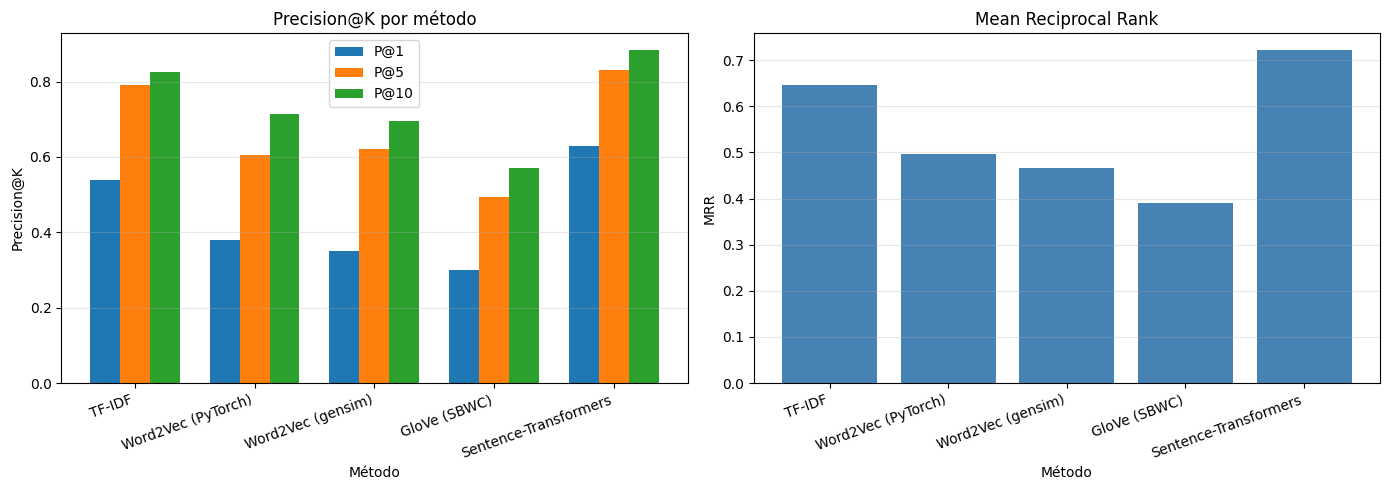

Gráfico guardado en data/evaluation_chart.png


In [ ]:
# Visualización de los resultados
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision@K
ax = axes[0]
k_values = [1, 5, 10]
x = np.arange(len(df_results))
width = 0.25

for i, k in enumerate(k_values):
    values = df_results[f'P@{k}'].values
    ax.bar(x + i*width, values, width, label=f'P@{k}')

ax.set_xlabel('Método')
ax.set_ylabel('Precision@K')
ax.set_title('Precision@K por método')
ax.set_xticks(x + width)
ax.set_xticklabels(df_results.index, rotation=20, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: MRR
ax = axes[1]
ax.bar(df_results.index, df_results['MRR'].values, color='steelblue')
ax.set_xlabel('Método')
ax.set_ylabel('MRR')
ax.set_title('Mean Reciprocal Rank')
ax.set_xticklabels(df_results.index, rotation=20, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(DATA_DIR / "evaluation_chart.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado en data/evaluation_chart.png")


## 9. Análisis cualitativo: ejemplos de queries

Veamos casos concretos donde los enfoques semánticos ganan o pierden contra TF-IDF.

In [ ]:
def show_top_results(query_idx, query_emb_dict, doc_emb_dict, eval_queries, all_docs, k=3):
    """Muestra los top-k resultados de cada método para una query dada."""
    query = eval_queries[query_idx]
    relevant_idx = query['relevant_idx']

    print(f"QUERY: '{query['query']}'")
    print(f"RELEVANTE: '{all_docs[relevant_idx][:200]}...'")
    print()

    for name, (q_embs, d_embs) in query_emb_dict.items():
        sims = cosine_similarity(q_embs[query_idx:query_idx+1], d_embs)[0]
        top = np.argsort(-sims)[:k]
        relevant_pos = np.where(np.argsort(-sims) == relevant_idx)[0][0] + 1

        print(f"--- {name} (relevante está en posición {relevant_pos}) ---")
        for i, doc_idx in enumerate(top):
            marker = " ✓" if doc_idx == relevant_idx else ""
            print(f"  {i+1}. [{sims[doc_idx]:.3f}]{marker} {all_docs[doc_idx][:120]}...")
        print()


# Construir diccionarios para la función
embedding_dict = {
    'TF-IDF': (query_emb_tfidf, doc_emb_tfidf),
    'w2v PyTorch': (query_emb_w2v_pytorch, doc_emb_w2v_pytorch),
    'GloVe': (query_emb_glove, doc_emb_glove),
    'SBERT': (query_emb_sbert, doc_emb_sbert),
}

# Mostrar 2 ejemplos
print("=" * 80)
print("EJEMPLO 1")
print("=" * 80)
show_top_results(0, embedding_dict, None, eval_queries, all_docs, k=3)

print("=" * 80)
print("EJEMPLO 2")
print("=" * 80)
show_top_results(5, embedding_dict, None, eval_queries, all_docs, k=3)


EJEMPLO 1
QUERY: 'está bien un poco de cafeína durante el embarazo'
RELEVANTE: 'No sabemos mucho sobre los efectos de la cafeína durante el embarazo en usted y su bebé. Por lo tanto, es mejor limitar la cantidad que recibe cada día. Si está embarazada, limite la cafeína a 200 mil...'

--- TF-IDF (relevante está en posición 1) ---
  1. [0.323] ✓ No sabemos mucho sobre los efectos de la cafeína durante el embarazo en usted y su bebé. Por lo tanto, es mejor limitar ...
  2. [0.285] Es posible que haya escuchado que demasiada cafeína puede causar un aborto espontáneo (cuando un bebé muere en el útero ...
  3. [0.229] La cantidad de cafeína en una pastilla de cafeína es equivalente a dos tazas de café. Las pastillas de cafeína pueden se...

--- w2v PyTorch (relevante está en posición 14) ---
  1. [0.901] Es posible que haya escuchado que demasiada cafeína puede causar un aborto espontáneo (cuando un bebé muere en el útero ...
  2. [0.895] Tal es el caso de las hojas de té negro. Estos conti

## 10. Guardar embeddings de documentos para el Notebook 5

In [ ]:
# Para el notebook de visualización (t-SNE), guardamos los embeddings de documentos
np.save(DATA_DIR / "doc_emb_w2v_pytorch.npy", doc_emb_w2v_pytorch)
np.save(DATA_DIR / "doc_emb_w2v_gensim.npy",  doc_emb_w2v_gensim)
np.save(DATA_DIR / "doc_emb_glove.npy",       doc_emb_glove)
np.save(DATA_DIR / "doc_emb_sbert.npy",       doc_emb_sbert)

# También las queries y los textos crudos
with open(DATA_DIR / "eval_docs.json", "w", encoding="utf-8") as f:
    json.dump({
        "all_docs": all_docs,
        "eval_queries": eval_queries,
    }, f, ensure_ascii=False)

print("Archivos guardados para Notebook 5:")
for f in ["doc_emb_w2v_pytorch.npy", "doc_emb_w2v_gensim.npy",
          "doc_emb_glove.npy", "doc_emb_sbert.npy", "eval_docs.json"]:
    p = DATA_DIR / f
    if p.exists():
        print(f"  ✓ {f} ({p.stat().st_size/1e6:.1f} MB)")

print("\n¡Notebook 4 completado!")


Archivos guardados para Notebook 5:
  ✓ doc_emb_w2v_pytorch.npy (2.0 MB)
  ✓ doc_emb_w2v_gensim.npy (2.0 MB)
  ✓ doc_emb_glove.npy (6.0 MB)
  ✓ doc_emb_sbert.npy (7.7 MB)
  ✓ eval_docs.json (2.1 MB)

¡Notebook 4 completado!
